# How Correlation Works — Step by Step

In [1]:
import pandas as pd
import numpy as np

# 6 tiny buildings — easy to follow by hand
data = pd.DataFrame({
    'sqft':  [10, 20, 30, 40, 50, 60],
    'EUI':   [50, 55, 65, 70, 80, 85]
})

# Step 1: averages
avg_sqft = data['sqft'].mean()
avg_eui  = data['EUI'].mean()
print(f"Average sqft: {avg_sqft}")
print(f"Average EUI:  {avg_eui}")
print()

Average sqft: 35.0
Average EUI:  67.5



In [3]:
# Step 2: how far is each building from the average?
data['sqft_diff'] = data['sqft'] - avg_sqft
data['eui_diff']  = data['EUI'] - avg_eui
print(data[['sqft', 'sqft_diff', 'EUI', 'eui_diff']])

   sqft  sqft_diff  EUI  eui_diff
0    10      -25.0   50     -17.5
1    20      -15.0   55     -12.5
2    30       -5.0   65      -2.5
3    40        5.0   70       2.5
4    50       15.0   80      12.5
5    60       25.0   85      17.5


In [4]:
# Step 3: multiply the two differences for each building
data['product'] = data['sqft_diff'] * data['eui_diff']
print(data[['sqft', 'sqft_diff', 'EUI', 'eui_diff', 'product']])
print()
print("Notice: when both diffs are negative (below avg), product is POSITIVE")
print("        when both diffs are positive (above avg), product is POSITIVE")
print("        -> they move together!")

   sqft  sqft_diff  EUI  eui_diff  product
0    10      -25.0   50     -17.5    437.5
1    20      -15.0   55     -12.5    187.5
2    30       -5.0   65      -2.5     12.5
3    40        5.0   70       2.5     12.5
4    50       15.0   80      12.5    187.5
5    60       25.0   85      17.5    437.5

Notice: when both diffs are negative (below avg), product is POSITIVE
        when both diffs are positive (above avg), product is POSITIVE
        -> they move together!


In [5]:
# Step 4 & 5: average the products and scale to -1 to 1
# (pandas .corr() does this for us)
manual_correlation = data['product'].sum() / (
    np.sqrt((data['sqft_diff']**2).sum()) * np.sqrt((data['eui_diff']**2).sum())
)
pandas_correlation = data['sqft'].corr(data['EUI'])

print(f"Our manual calculation: {manual_correlation:.4f}")
print(f"Pandas .corr():        {pandas_correlation:.4f}")
print()
print("Close to 1 = when sqft goes up, EUI goes up too")

Our manual calculation: 0.9954
Pandas .corr():        0.9954

Close to 1 = when sqft goes up, EUI goes up too


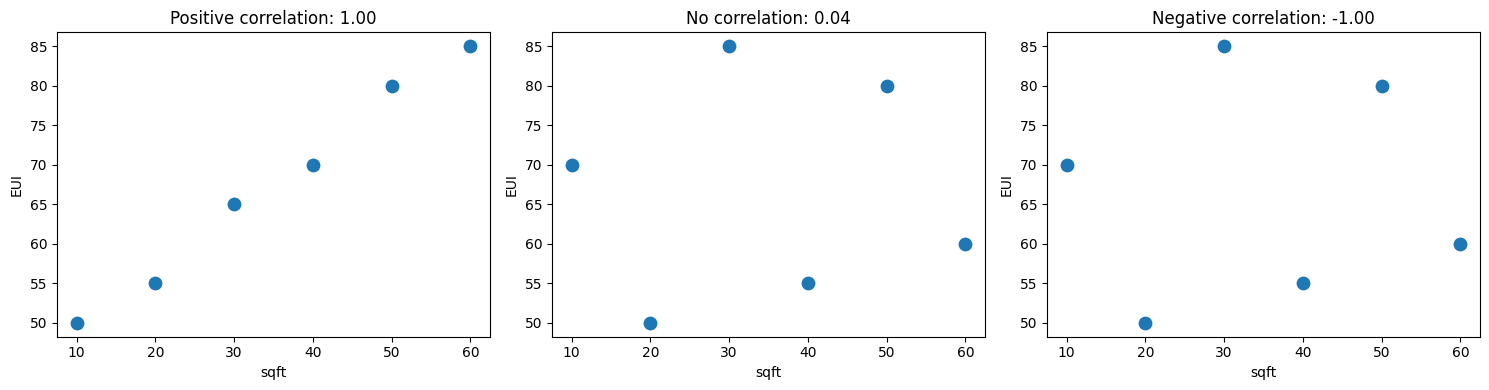

In [6]:
# Now let's SEE three different scenarios
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Strong positive: bigger sqft = higher EUI
x = [10, 20, 30, 40, 50, 60]
y_pos = [50, 55, 65, 70, 80, 85]
axes[0].scatter(x, y_pos, s=80)
axes[0].set_title(f'Positive correlation: {np.corrcoef(x, y_pos)[0,1]:.2f}')
axes[0].set_xlabel('sqft')
axes[0].set_ylabel('EUI')

# No correlation: sqft tells you nothing about EUI
y_none = [70, 50, 85, 55, 80, 60]
axes[1].scatter(x, y_none, s=80)
axes[1].set_title(f'No correlation: {np.corrcoef(x, y_none)[0,1]:.2f}')
axes[1].set_xlabel('sqft')
axes[1].set_ylabel('EUI')

# Negative: bigger sqft = lower EUI
y_neg = [85, 80, 70, 65, 55, 50]
axes[2].scatter(x, y_none, s=80)
axes[2].set_title(f'Negative correlation: {np.corrcoef(x, y_neg)[0,1]:.2f}')
axes[2].set_xlabel('sqft')
axes[2].set_ylabel('EUI')

plt.tight_layout()
plt.show()